# From Speech to Print

## Setup

Agregamos la carpeta padre al Path para poder importar el módulo `cowaver`:

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import cowaver

Definimos una función que nos será util para escuchar audios.

In [2]:
import io
import torch
import torchaudio
import ipywidgets as widgets
from cowaver.utils import AUDIO_SAMPLE_RATE

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

Configuramos las constantes de este notebook:

In [3]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

# Idioma, puede ser "french" o "spanish"
LANGUAGE = "spanish"

# Tamaño del dataset disponible
DATASET_SIZE = 480

# URL al checkpoint de CORnet-Z
CORNET_CKPT_URL = "https://s3.amazonaws.com/cornet-models/cornet_z-5c427c9c.pth"

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

print(f"Buscando {compressed_phones_path}", end="... ")
print("OK" if compressed_phones_path.exists() else "ERROR")

print(f"Buscando {compressed_spoken_path}", end="... ")
print("OK" if compressed_spoken_path.exists() else "ERROR")

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando ../spanish/kalulu-phones-480.tar.xz... OK
Buscando ../spanish/kalulu-spoken-480.tar.xz... OK


## Conjuntos de datos: TinyPairedMel

El conjunto de datos se divide en _Training Set_ y _Generalization Set_. El primero contiene un número de palabras con las que se entrenará la conciencia fonológica, mientras que el segundo contendrá palabras no vistas (pero sí por el Speech Autoencoder), que servirá para poner a prueba la capacidad de generalización de la conciencia fonológica.

Ejecutá la celda siguiente para descomprimir los datos y armar los conjuntos de _Training_ y _Generalization_.

In [4]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases
from cowaver.datamodules import TinyPairedMel

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Total de palabras:", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

full_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
training_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
generalization_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)

Descomprimiendo ../spanish/kalulu-phones-480.tar.xz en ../spanish/data/kalulu-phones-480... YA EXISTE
Descomprimiendo ../spanish/kalulu-spoken-480.tar.xz en ../spanish/data/kalulu-spoken-480... YA EXISTE
Total de palabras: 480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abierto', 'adulto', 'aire', 'alta', 'alumno', 'ama', 'ancho', 'artista', 'atleta', 'azúcar', 'bandera', 'calle', 'calor', 'cero', 'cerro', 'cohete', 'con', 'copa', 'cruzar', 'culpa', 'dado', 'dama', 'dejar', 'doce', 'enseña', 'era', 'esquina', 'fama', 'faro', 'feliz', 'fino', 'fruta', 'gracias', 'grande', 'helado', 'himno', 'idea', 'jugar', 'lava', 'lengua', 'limpio', 'los', 'luchar', 'magia', 'mancha', 'manga', 'marzo', 'medida', 'mes', 'miedo', 'modelo', 'moneda', 'montaña', 'mágico', 'música', 'niños', 'novios', 'nube', 'nudo', 'nueve', 'nuevo', 'octubre', 'oficina', 'ojo', 'parque', 'paseo', 'persona', 'pie', 'piel', 'pino', 'pintor', 'pintura', 'plana', 'planta', 'pluma', 'ratones', 'raíz', 'reino', 'ro

La siguiente celda permite explorar el conjunto de datos:

In [5]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        plt.show()

    display(widgets.VBox([out, widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform)])]))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Speech Autoencoder

### Definición

In [7]:
from cowaver.modules.reading import SpeechAutoEncoder

speech_autoencoder = SpeechAutoEncoder(h_dim=128, n_filters=16)
print(speech_autoencoder)

SpeechAutoEncoder(
  (encoder): ConvEncoder(
    (bias): BiasLayer()
    (conv_1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (conv_2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (lin): Linear(in_features=47232, out_features=128, bias=True)
  )
  (decoder): ConvDecoder(
    (bias): BiasLayer()
    (deconv_2): ConvTranspose2d(16, 1, kernel_size=(5, 5), stride=(1, 1))
    (deconv_1): ConvTranspose2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (unflatten): Unflatten(dim=-1, unflattened_size=(16, 41, 72))
    (lin): Linear(in_features=128, out_features=47232, bias=True)
  )
)


### Entrenamiento

In [8]:
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4,
    patience=3
)

# Uncomment to train
#
sembrar_semilla(40)
speech_autoencoder = SpeechAutoEncoder(h_dim=128, n_filters=16)
speech_autoencoder, train_history = entrenar_red(net=speech_autoencoder, data=full_data, programme=programme)
guardar_checkpoint(speech_autoencoder, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 40... OK
Buscando dispositivo... MPS
Red speech_autoencoder_hd128_nf16_sl49_mb80
Época 1/30 | train_loss=1.9274 | val_loss=0.6707
Época 2/30 | train_loss=0.4759 | val_loss=0.3974
Época 3/30 | train_loss=0.3516 | val_loss=0.3149
Época 4/30 | train_loss=0.2697 | val_loss=0.2368
Época 5/30 | train_loss=0.2719 | val_loss=0.2137
Época 6/30 | train_loss=0.2399 | val_loss=0.2596
Época 7/30 | train_loss=0.1862 | val_loss=0.2061
Época 8/30 | train_loss=0.1926 | val_loss=0.2080
Época 9/30 | train_loss=0.1832 | val_loss=0.1925
Época 10/30 | train_loss=0.1563 | val_loss=0.1537
Época 11/30 | train_loss=0.1431 | val_loss=0.1515
Época 12/30 | train_loss=0.1316 | val_loss=0.1530
Época 13/30 | train_loss=0.1208 | val_loss=0.1280
Época 14/30 | train_loss=0.1156 | val_loss=0.1228
Época 15/30 | train_loss=0.1087 | val_loss=0.1196
Época 16/30 | train_loss=0.1035 | val_loss=0.1284
Época 17/30 | train_loss=0.0980 | val_loss=0.1134
Época 18/30 | train_loss=0.0926 | val_loss=0.1128
Época 19/3

### Evaluación

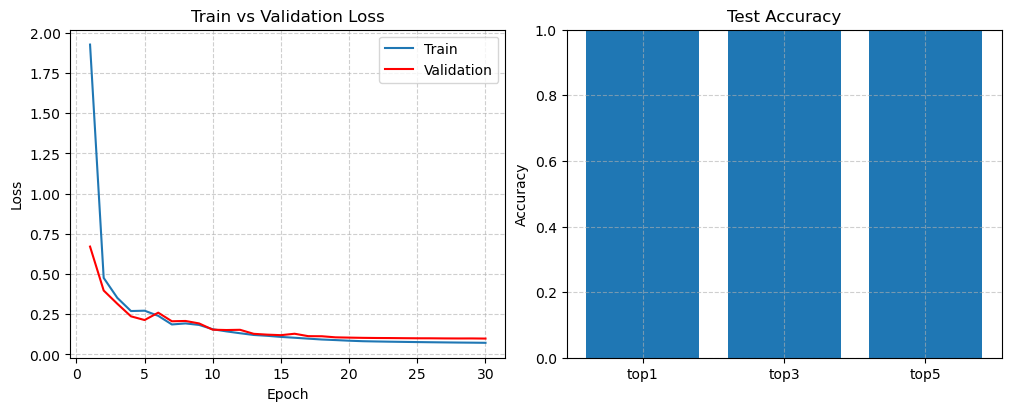

In [9]:
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

speech_autoencoder = SpeechAutoEncoder(h_dim=128, n_filters=16)
train_history = cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
test_results = evaluar_red(speech_autoencoder, full_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(test_results, ax=axes[1])
plt.show()

### Exploración

In [11]:
import matplotlib.pyplot as plt
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

speech_autoencoder = SpeechAutoEncoder(h_dim=128, n_filters=16)
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
speech_autoencoder.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, _, spoken_mel), target = exploration_set[idx]
    spoken_waveform = extraer_waveform(spoken_mel)

    with torch.no_grad():
        reconstructed_mel = speech_autoencoder(spoken_mel.unsqueeze(1).transpose(2, 3))
    reconstructed_mel = reconstructed_mel.squeeze(1).transpose(1, 2)
    reconstructed_waveform = extraer_waveform(reconstructed_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(spoken_waveform, ax=axes[0][0])
        graficar_mel(spoken_mel, ax=axes[0][1])
        graficar_waveform(reconstructed_waveform, ax=axes[1][0])
        graficar_mel(reconstructed_mel, ax=axes[1][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(spoken_waveform), audio_widget(reconstructed_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Red de conciencia fonológica

### Definición

In [12]:
from cowaver.modules.reading import PhonologicalAwareness

phonological_awareness = PhonologicalAwareness(h_dim=128, n_filters=16)
print(phonological_awareness)

PhonologicalAwareness(
  (encoder): ConvEncoder(
    (bias): BiasLayer()
    (conv_1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (conv_2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (lin): Linear(in_features=47232, out_features=128, bias=True)
  )
  (decoder): ConvDecoder(
    (bias): BiasLayer()
    (deconv_2): ConvTranspose2d(16, 1, kernel_size=(5, 5), stride=(1, 1))
    (deconv_1): ConvTranspose2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (unflatten): Unflatten(dim=-1, unflattened_size=(16, 41, 72))
    (lin): Linear(in_features=128, out_features=47232, bias=True)
  )
)


### Entrenamiento

In [14]:
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4,
    patience=3
)

# Uncomment to train
#
sembrar_semilla(40)
phonological_awareness = PhonologicalAwareness(h_dim=128, n_filters=16)

speech_autoencoder = SpeechAutoEncoder(h_dim=128, n_filters=16)
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
phonological_awareness.load_state_dict(speech_autoencoder.state_dict())

phonological_awareness, train_history = entrenar_red(net=phonological_awareness, data=training_data, programme=programme)
guardar_checkpoint(phonological_awareness, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 40... OK
Buscando dispositivo... MPS
Red phonological_awareness_hd128_nf16_sl49_mb80
Época 1/30 | train_loss=1.3527 | val_loss=0.8769
Época 2/30 | train_loss=0.6491 | val_loss=0.6740
Época 3/30 | train_loss=0.4320 | val_loss=0.6031
Época 4/30 | train_loss=0.3250 | val_loss=0.5446
Época 5/30 | train_loss=0.2632 | val_loss=0.5266
Época 6/30 | train_loss=0.2241 | val_loss=0.5119
Época 7/30 | train_loss=0.1963 | val_loss=0.5030
Época 8/30 | train_loss=0.1726 | val_loss=0.4935
Época 9/30 | train_loss=0.1519 | val_loss=0.4962
Época 10/30 | train_loss=0.1364 | val_loss=0.4912
Época 11/30 | train_loss=0.1260 | val_loss=0.4866
Época 12/30 | train_loss=0.1151 | val_loss=0.4859
Época 13/30 | train_loss=0.1071 | val_loss=0.4815
Época 14/30 | train_loss=0.0998 | val_loss=0.4833
Época 15/30 | train_loss=0.0943 | val_loss=0.4837
Época 16/30 | train_loss=0.0900 | val_loss=0.4855
El entrenamiento finalizó de forma prematura.
Guardando checkpoint en ../spanish/checkpoints/480/phonologi

### Evaluación

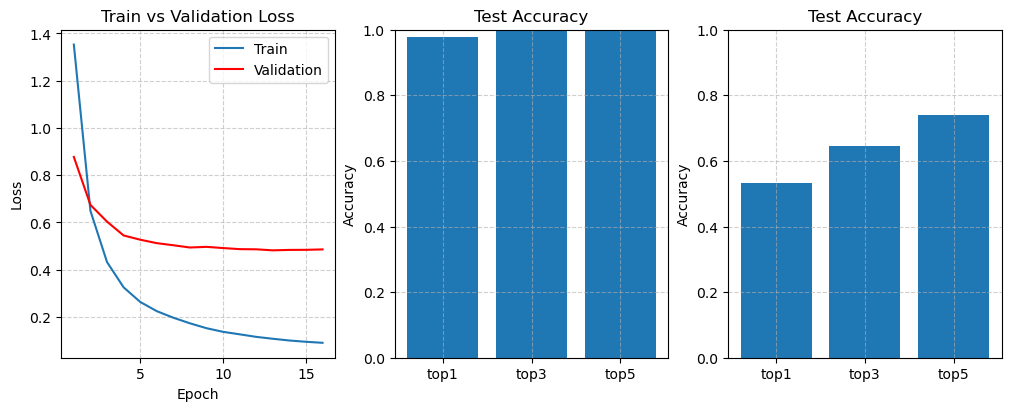

In [16]:
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_awareness = PhonologicalAwareness(h_dim=128, n_filters=16)
train_history = cargar_checkpoint(phonological_awareness, folder=checkpoints_path, silent=True)
training_test_results = evaluar_red(phonological_awareness, training_data)
generalization_test_results = evaluar_red(phonological_awareness, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

### Exploración

In [18]:
import matplotlib.pyplot as plt
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_awareness = PhonologicalAwareness(h_dim=128, n_filters=16)
cargar_checkpoint(phonological_awareness, folder=checkpoints_path, silent=True)
phonological_awareness.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    phonetized_mel = phonetized_mel.unsqueeze(1).transpose(2, 3)
    with torch.no_grad():
        h = phonological_awareness.encoder(phonetized_mel)
        mel_hat = phonological_awareness.decoder(h)
    predicted_mel = mel_hat.squeeze(1).transpose(1, 2)
    predicted_waveform = extraer_waveform(predicted_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(3, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        graficar_embedding(h, ax=axes[2][0], vmin=h.min(), vmax=h.max())
        graficar_mel(predicted_mel, ax=axes[2][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform), audio_widget(predicted_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Ruta fonológica de la lectura

### Definición

In [20]:
from cowaver.modules.reading import PhonologicalRoute

phonological_route = PhonologicalRoute(h_dim=128, n_filters=16)
print(phonological_route)

PhonologicalRoute(
  (cornet): DataParallel(
    (module): Sequential(
      (V1): CORblock_Z(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V2): CORblock_Z(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V4): CORblock_Z(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (IT): CORblock_Z(
        (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      

### Entrenamiento

In [22]:
from cowaver.modules.reading import PhonologicalRoute
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import cargar_checkpoint, guardar_checkpoint

programme = TrainProgramme(
    theta_max=60,
    epsilon_zero=1e-3,
    theta=45,
    epsilon_theta=1e-4,
    patience=7
)

# Uncomment to train
#
sembrar_semilla(42)
phonological_route = PhonologicalRoute(h_dim=128, n_filters=16)

checkpoint = torch.utils.model_zoo.load_url(CORNET_CKPT_URL, map_location=torch.device("cpu"))
phonological_route.cornet.load_state_dict(checkpoint["state_dict"], strict=False)

cargar_checkpoint(phonological_route.phonological_awareness, folder=checkpoints_path, silent=True)

print("Midiendo estadística", end="... ")
all_h = []
phonological_route.phonological_awareness.eval()
with torch.no_grad():
    for batch in training_data.train_loader():
        (_, phonetized_mel, _), labels = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        h = phonological_route.phonological_awareness.encoder(phonetized_mel)
        all_h.append(h)
all_h = torch.cat(all_h, dim=0)
h_mean = all_h.mean(dim=0)
h_std = all_h.std(dim=0)
phonological_route.set_h_stats(h_mean, h_std)
print("OK")

phonological_route, train_history = entrenar_red(net=phonological_route, data=training_data, programme=programme)
guardar_checkpoint(phonological_route, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 42... OK
Midiendo estadística... OK
Buscando dispositivo... MPS
Red phonological_route_hd128_nf16_sl49_mb80
Época 1/60 | train_loss=0.8765 | val_loss=0.6005
Época 2/60 | train_loss=0.6905 | val_loss=0.4947
Época 3/60 | train_loss=0.5701 | val_loss=0.4290
Época 4/60 | train_loss=0.4938 | val_loss=0.4038
Época 5/60 | train_loss=0.4499 | val_loss=0.3868
Época 6/60 | train_loss=0.4213 | val_loss=0.3797
Época 7/60 | train_loss=0.4018 | val_loss=0.3708
Época 8/60 | train_loss=0.3877 | val_loss=0.3611
Época 9/60 | train_loss=0.3771 | val_loss=0.3591
Época 10/60 | train_loss=0.3711 | val_loss=0.3617
Época 11/60 | train_loss=0.3644 | val_loss=0.3577
Época 12/60 | train_loss=0.3597 | val_loss=0.3521
Época 13/60 | train_loss=0.3556 | val_loss=0.3562
Época 14/60 | train_loss=0.3519 | val_loss=0.3573
Época 15/60 | train_loss=0.3487 | val_loss=0.3529
Época 16/60 | train_loss=0.3461 | val_loss=0.3527
Época 17/60 | train_loss=0.3439 | val_loss=0.3524
Época 18/60 | train_loss=0.3420 |

### Evaluación

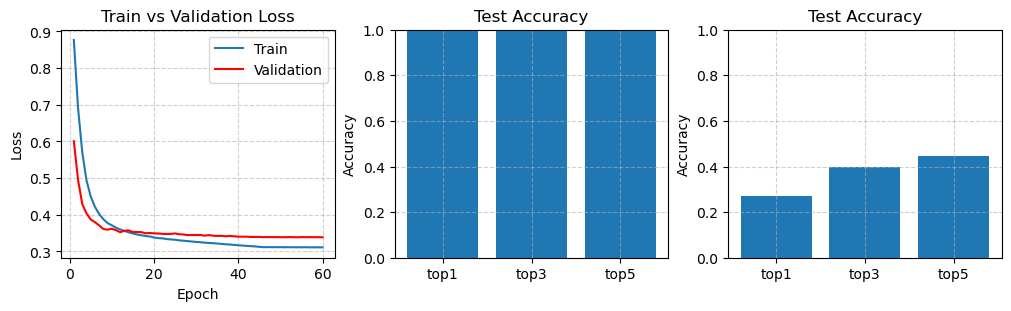

In [26]:
from cowaver.modules.reading import PhonologicalRoute
from cowaver.checkpoints import cargar_checkpoint
from cowaver.utils import evaluar_red
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_route = PhonologicalRoute(h_dim=128, n_filters=16)
train_history = cargar_checkpoint(phonological_route, folder=checkpoints_path, silent=True)
training_test_results = evaluar_red(phonological_route, training_data)
generalization_test_results = evaluar_red(phonological_route, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

### Exploración

In [27]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform, make_image
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_route = PhonologicalRoute(h_dim=128, n_filters=16)
cargar_checkpoint(phonological_route, folder=checkpoints_path, silent=True)
phonological_route.eval()

@widgets.interact(word="buzo")
def explore_phonological_route(word: str):
    image = make_image(word)
    with torch.no_grad():
        mel, h = phonological_route(image)
    mel = mel.squeeze(1).transpose(1, 2)
    waveform = extraer_waveform(mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
        fig.suptitle(word)
        graficar_waveform(waveform, ax=axes[0])
        graficar_mel(mel, ax=axes[1])
        graficar_embedding(h, ax=axes[2], vmin=h.min(), vmax=h.max())
        plt.show()
        
    display(widgets.VBox([out, audio_widget(waveform)]))

interactive(children=(Text(value='buzo', description='word'), Output()), _dom_classes=('widget-interact',))